# Phase retrieval from through-focus data using the Gerchberg-Saxton algorithm
awojdyla@lbl.gov, ramigdal@lbl.gov, Feb 2026

Text(0.5, 1.0, 'focusing from an (2.8x?) objective lens with 34 mm focal length')

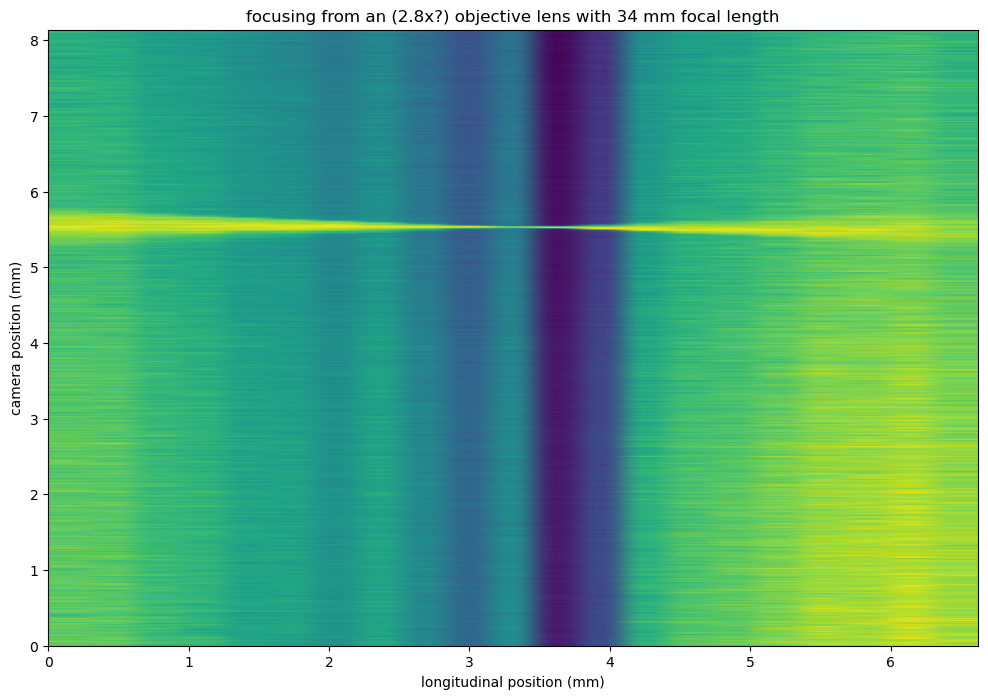

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# testing
#img = np.load(os.path.join("/Users/awojdyla/data/Topolino_20260206", "Topolino_20260206_001_021.npy"))

save_dir = "/Users/awojdyla/data/Topolino_20260206"
#data available here:
# https://drive.google.com/drive/folders/10M-nmucJpVLdx42It7txgTJudc-UXtX-?usp=drive_link

# physical parameters
pixel_size_m = 3.45e-6  #
# basler a2A1920-51gcBAS

scan_range_ct = 200000
apt_step_size_mm = 40.7e-06
# from calibration 2026.02.06LensDataPt2.ipynb
# https://www.thorlabs.com/100-mm-3.94-inch--compact-motorized-translation-stage?tabName=Specs

total_range_mm = scan_range_ct * apt_step_size_mm  # 0 to 2
step_mm = total_range_mm / 20  # 21 points

I_z = np.zeros((1920, 21))
plt.figure(figsize=(12, 8))
position_mm = np.zeros(21)
for i in range(21):
    position_mm[i] = 0 + i * step_mm
    I_z[:,i] = np.load(os.path.join(save_dir, f"one_dim_sum_{i+1:03d}.npy"))
    I_z[:,i] /= np.max(I_z[:,i])  # normalize for better contrast

plt.imshow(I_z, extent=[0, 1920*pixel_size_m*1e3, position_mm[0], position_mm[-1]], aspect='auto', origin='lower')
plt.xlabel('longitudinal position (mm)')
plt.ylabel('camera position (mm)')
plt.title('focusing from an (2.8x?) objective lens with 34 mm focal length')
#plt.ylim((0.7,0.8))
#plt.title('Intensity map at x=3200 µm for z from -2mm to +2mm')


## Some beam statistics

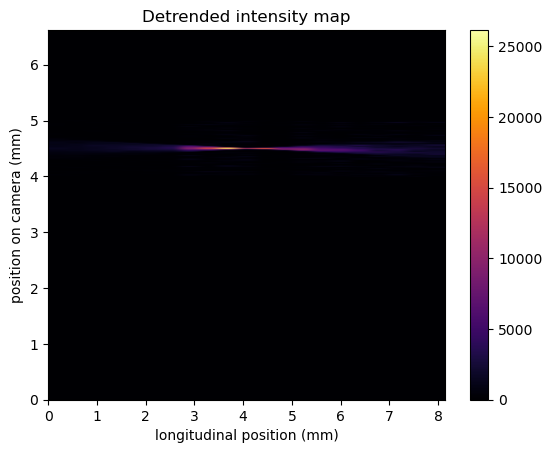

In [2]:
from scipy.signal import detrend
x_m = np.arange(1920)*pixel_size_m


mu_m    = np.zeros(21)
sigma_m = np.zeros(21)
Id = np.zeros((1920, 21))
for i in range(21):
    I_z[:,i] = np.load(os.path.join(save_dir, f"one_dim_sum_{i+1:03d}.npy"))
    Id[:,i] = detrend(I_z[:,i]) # remove backgound light from the room
    Id[Id[:,i]<0,i] = 0 # remove negative values after detrending 
    Id[(x_m<4e-3) | (x_m>5e-3),i] = 0 # remove values outside the range (remove noise)

    g = Id[:,i]/np.max(Id[:,i])  # normalize for better contrast
    g[g<0.3] = 0  # thresholding to reduce noise

    x_mean_estimate_m = np.sum(x_m*g)/np.sum(g)#moment: sum of values * their position / sum of all values
    x_std_estimate_m  = np.sqrt(np.sum((x_m - x_mean_estimate_m)**2*g)/np.sum(g))
    mu_m[i] = x_mean_estimate_m
    sigma_m[i] = x_std_estimate_m

plt.imshow(Id, extent=[ position_mm[0], position_mm[-1], x_m[0]*1e3, x_m[-1]*1e3], aspect='auto', origin='lower')
plt.xlabel('longitudinal position (mm)')
plt.ylabel('position on camera (mm)')
plt.title('Detrended intensity map')
plt.colorbar()
plt.set_cmap('inferno')


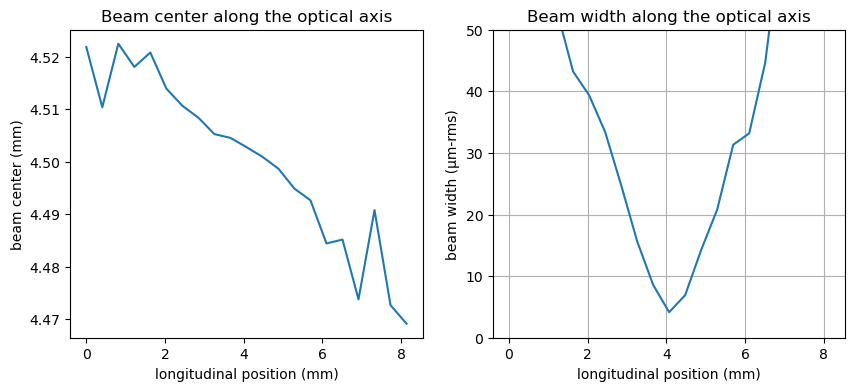

In [3]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(position_mm, mu_m*1e3, label='mean (µm)')
plt.xlabel('longitudinal position (mm)')
plt.ylabel('beam center (mm)')
plt.title("Beam center along the optical axis")

plt.subplot(1,2,2)
plt.plot(position_mm, sigma_m*1e6, label='std (µm)')
#plt.plot(np.arange(len(sigma_m)), sigma_m*1e6, label='std (µm)')
plt.xlabel('longitudinal position (mm)')
plt.ylabel('beam width (µm-rms)')
plt.title("Beam width along the optical axis")
plt.ylim((0,50))
plt.grid()
plt.show()

## Gerchberg-Saxton phase retrieval

In [4]:
def propTF(uin_V_m, L_m, lambda_m, z_m):
    M = uin_V_m.size        # number of samples (grid points)
    dx_m = L_m/M            # grid spacing
    k_1_m = 2*np.pi/lambda_m # wavenumber

    # Frequency coordinates
    fx_1_m = np.linspace(-1/(2*dx_m), 1/(2*dx_m) - (1/L_m), M)
    
    # Transfer function for Fresnel propagation
    H = np.exp(-1j * np.pi * lambda_m * z_m * (fx_1_m**2))
    H = np.fft.fftshift(H)

    # Fourier transform input field
    Uin_V_m = np.fft.fft(np.fft.fftshift(uin_V_m))

    # Multiply in Fourier space
    Uout_V_m = H * Uin_V_m

    # Inverse FFT → propagated field
    uout_V_m = np.fft.ifftshift(np.fft.ifft(Uout_V_m))
    return uout_V_m

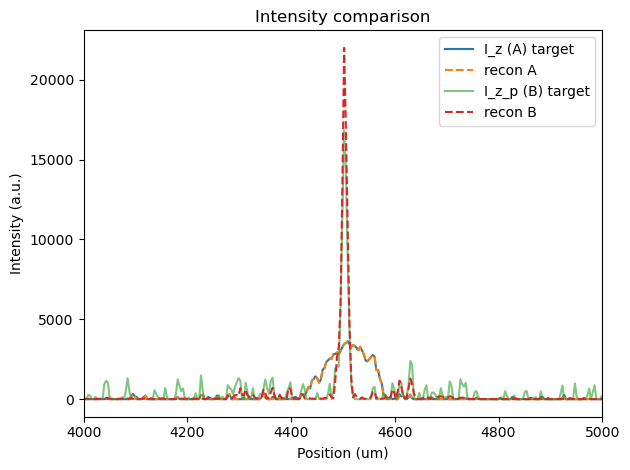

In [5]:
# Gerchberg-Saxton phase retrieval between I_z (plane A) and I_z_p (plane B)
# Uses existing variables: I_z, I_z_p, Dx_m, wavelength_m, z_scan, Ef, E_z, x_m, propTF

wavelength_m = 633e-9
Dx_m = 1920*pixel_size_m

oversampling_factor = 1
dx_m = pixel_size_m/oversampling_factor
xi_m = np.arange(1920*oversampling_factor)*dx_m

idx_A = 6   # index used earlier for I_z
idx_B = 10   # index used earlier for I_z_p

# idx_A = 7   # index used earlier for I_z
# idx_B = 11   # index used earlier for I_z_p

# propagation distance from A -> B
dz_m = (position_mm[idx_B] - position_mm[idx_A]) * 1e-3  # convert mm to meters

Idi_A = np.interp(xi_m, x_m, Id[:, idx_A])  # interpolate intensity at plane A to finer grid for better accuracy
Idi_B = np.interp(xi_m, x_m, Id[:, idx_B])  # interpolate intensity at plane B to finer grid for better accuracy

#initiates amplitudes "from measurements" 
amp_A = np.sqrt(np.maximum(Idi_A, 0))
amp_B = np.sqrt(np.maximum(Idi_B, 0))

amp_A[amp_A<np.max(amp_A)*0.2] = 0  # avoid zeros for better numerical stability
amp_B[amp_B<np.max(amp_B)*0.2] = 0  # avoid zeros for better numerical stability

# initial phase guess at plane A: use Ef phase if available, otherwise random
init_phase = np.random.uniform(-np.pi, np.pi, size=amp_A.size)
init_phase = 0*np.zeros_like(xi_m)  # start with zero phase guess for better convergence

u_A = amp_A * np.exp(1j * init_phase)

n_iter = 200
errors = np.zeros(n_iter)

for k in range(n_iter):
    # forward propagate A -> B
    u_B = propTF(u_A, Dx_m, wavelength_m, dz_m)

    # enforce amplitude at B
    u_B = amp_B * np.exp(1j * np.angle(u_B))

    # back propagate B -> A
    u_A = propTF(u_B, Dx_m, wavelength_m, -dz_m)

    # enforce amplitude at A
    u_A = amp_A * np.exp(1j * np.angle(u_A))

    # compute error at B (normalized RMS of intensity)
    recon_B = propTF(u_A, Dx_m, wavelength_m, dz_m)
    err = np.linalg.norm(np.abs(recon_B)**2 - Idi_B) / (np.linalg.norm(Idi_B) + 1e-20)
    errors[k] = err

# final reconstructed fields
recon_A = u_A
recon_B = propTF(recon_A, Dx_m, wavelength_m, dz_m)

# plots: error convergence, intensity comparison, phase comparison
# plt.figure(figsize=(10, 3))
# plt.subplot(1, 3, 1)
# plt.semilogy(errors + 1e-20)
# plt.xlabel('Iteration')
# plt.ylabel('Relative intensity error (B)')
# plt.title('Convergence')

plt.plot(xi_m*1e6, Idi_A, label='I_z (A) target')
plt.plot(xi_m*1e6, np.abs(recon_A)**2, '--', label='recon A')
plt.plot(xi_m*1e6, Idi_B, label='I_z_p (B) target', alpha=0.6)
plt.plot(xi_m*1e6, np.abs(recon_B)**2, '--', label='recon B')
plt.xlim((4e3, 5e3))
plt.xlabel('Position (um)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.title('Intensity comparison')


plt.tight_layout()
plt.show()

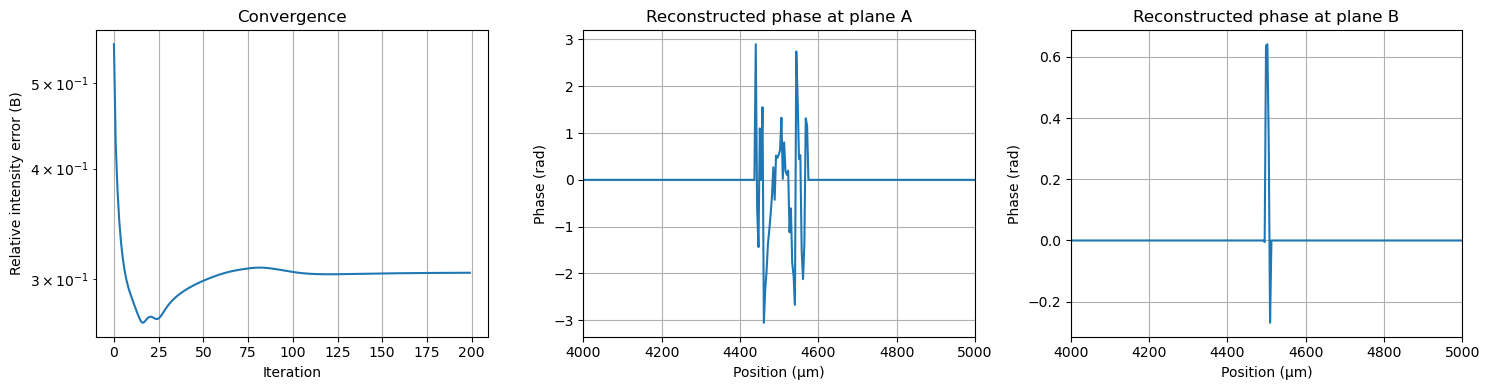

In [6]:
plt.figure(figsize=(15, 4))

# Plot convergence
plt.subplot(1, 3, 1)
plt.semilogy(errors + 1e-20)
plt.xlabel('Iteration')
plt.ylabel('Relative intensity error (B)')
plt.title('Convergence')
plt.grid(True)

# Plot reconstructed phase at plane A
plt.subplot(1, 3, 2)
plt.plot(xi_m*1e6, np.angle(recon_A)*(Idi_A>np.max(Idi_A)*0.3))  # only plot phase where amplitude is significant
plt.xlim((4e3, 5e3))
plt.xlabel('Position (μm)')
plt.ylabel('Phase (rad)')
plt.title('Reconstructed phase at plane A')
plt.grid(True)

# Plot reconstructed phase at plane B
plt.subplot(1, 3, 3)
plt.plot(xi_m*1e6, np.angle(recon_B)*(Idi_B>np.max(Idi_B)*0.3))  # only plot phase where amplitude is significant
plt.xlim((4e3, 5e3))
plt.xlabel('Position (μm)')
plt.ylabel('Phase (rad)')
plt.title('Reconstructed phase at plane B')
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
#aliasing condition for accurate Fresnel propagation:
dx_m>(wavelength_m*dz_m/Dx_m)
dx_m/(wavelength_m*dz_m/Dx_m)


np.float64(22.175902744623123)

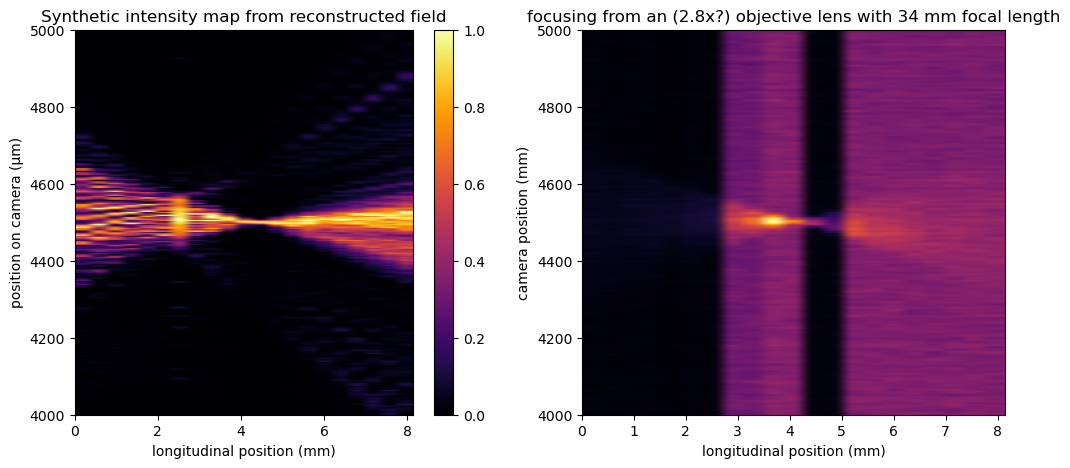

In [8]:
I_synthetic = np.zeros((xi_m.size, 21))
for i in range(21):
    I_synthetic[:, i] = np.abs(propTF(u_A, Dx_m, wavelength_m, (position_mm[i]-position_mm[idx_A])*1e-3))**2
    I_synthetic[:, i] /= np.max(I_synthetic[:, i])  # normalize for better contrast

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.imshow(I_synthetic, extent=[ position_mm[0], position_mm[-1], xi_m[0]*1e6, xi_m[-1]*1e6], aspect='auto', origin='lower')
plt.xlabel('longitudinal position (mm)')
plt.ylabel('position on camera (µm)')
plt.title('Synthetic intensity map from reconstructed field')
plt.colorbar()
plt.set_cmap('inferno')
plt.ylim((4e3, 5e3))


plt.subplot(1,2,2)
plt.imshow(I_z, extent=[ position_mm[0], position_mm[-1], x_m[0]*1e6, x_m[-1]*1e6], aspect='auto', origin='lower')
plt.xlabel('longitudinal position (mm)')
plt.ylabel('camera position (mm)')
plt.title('focusing from an (2.8x?) objective lens with 34 mm focal length')
plt.set_cmap('inferno')
plt.ylim((4e3, 5e3))

plt.show()
